<a href="https://colab.research.google.com/github/vaisanthragavc2025-pixel/vaisanth-EDA/blob/main/25BAI0145_EXP8_01.09.2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Dimensionality Reduction and Analysis
This notebook performs dimensionality reduction using PCA and t-SNE on the MNIST dataset and evaluates the impact on digit recognition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# Part A: Data Understanding and Preprocessing
print("Fetching MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

# Metadata
n_samples, n_features = X.shape
n_classes = len(np.unique(y))
img_dim = int(np.sqrt(n_features))

print(f'Number of samples: {n_samples}')
print(f'Number of classes: {n_classes}')
print(f'Image dimensions: {img_dim}x{img_dim}')

# Normalize pixel values to [0, 1]
X = X / 255.0

Fetching MNIST dataset...
Number of samples: 70000
Number of classes: 10
Image dimensions: 28x28


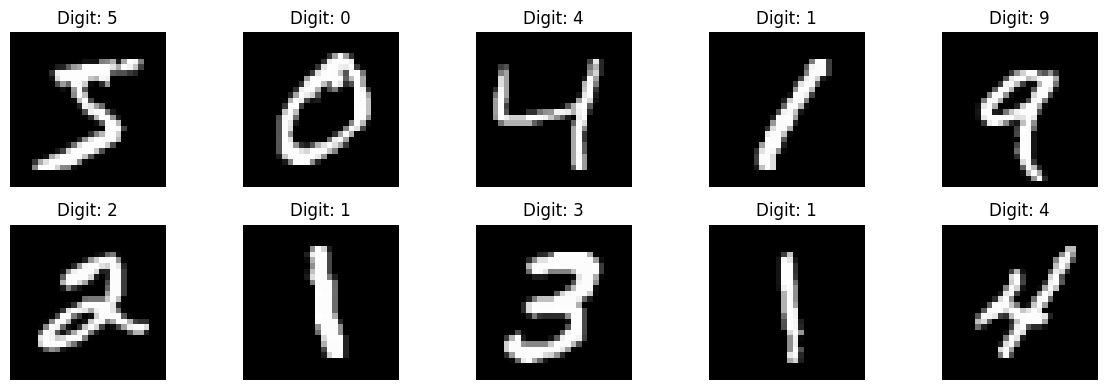

In [2]:
# Visualize 10 sample digits
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Digit: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Part C: t-SNE Visualization
t-SNE is a non-linear dimensionality reduction technique. We will apply it to the data and experiment with different perplexity values.

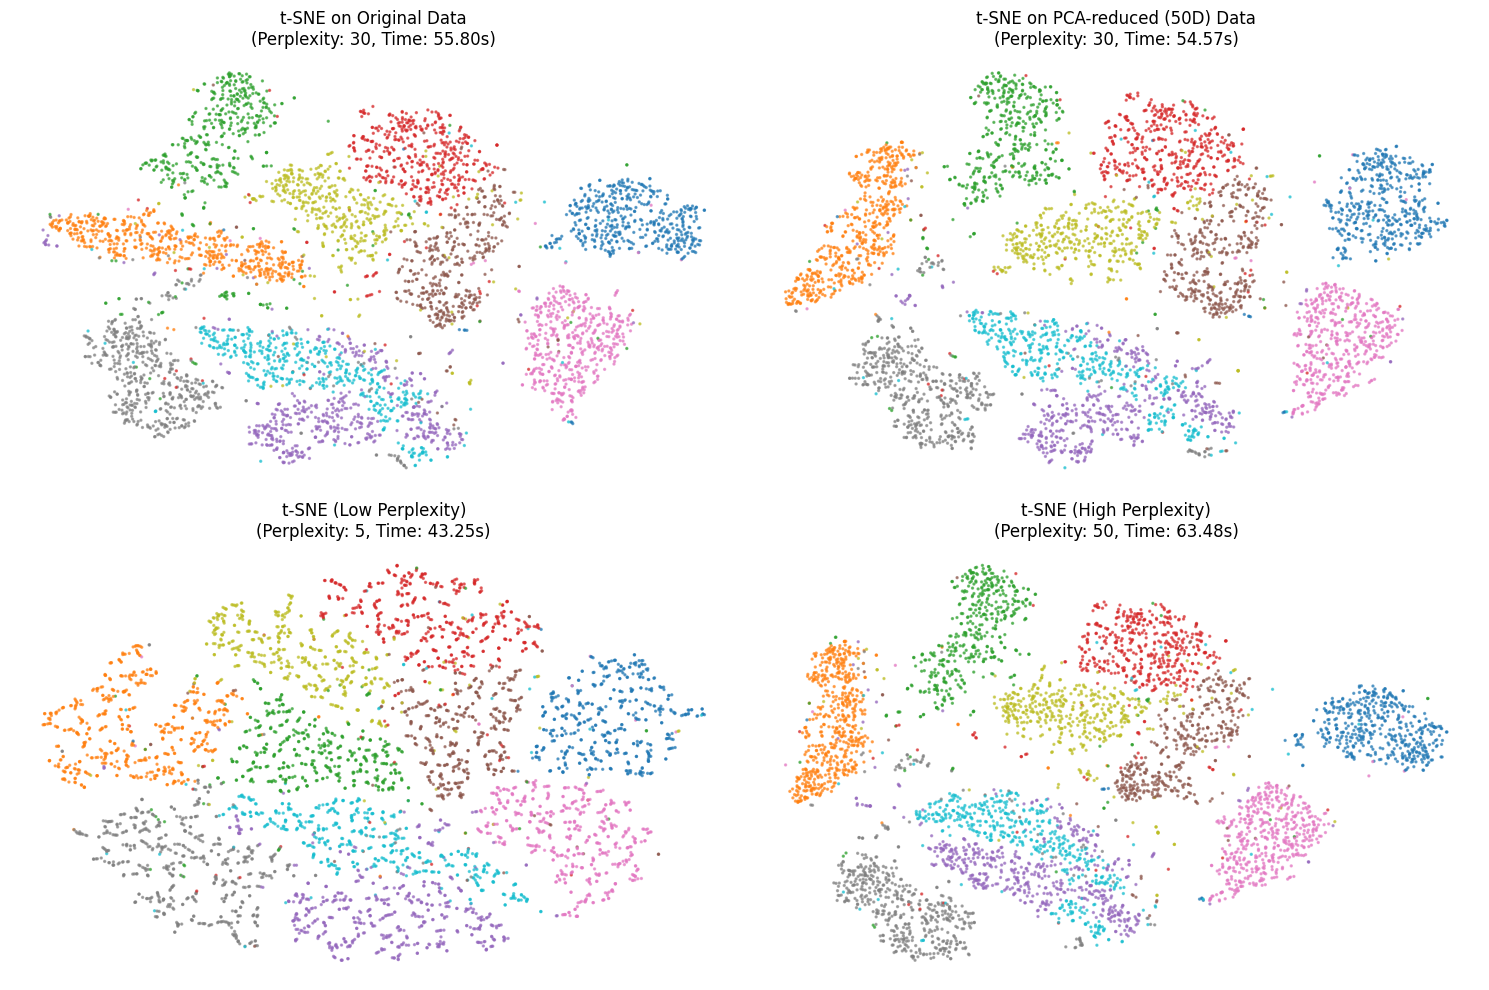

In [4]:
from sklearn.manifold import TSNE
import time

# Using a subset for faster computation in t-SNE
n_subset = 5000
X_subset = X[:n_subset]
y_subset = y[:n_subset]
X_pca_50_subset = X_pca_50[:n_subset] if 'X_pca_50' in locals() else None

def plot_tsne(data, title, perplexity=30):
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
    start = time.time()
    X_tsne = tsne.fit_transform(data)
    end = time.time()

    plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_subset.astype(int), cmap='tab10', alpha=0.6, s=2)
    plt.title(f"{title}\n(Perplexity: {perplexity}, Time: {end-start:.2f}s)")
    plt.axis('off')

plt.figure(figsize=(15, 10))

# Compare t-SNE on Original vs PCA-reduced data
plt.subplot(2, 2, 1)
plot_tsne(X_subset, "t-SNE on Original Data")

plt.subplot(2, 2, 2)
plot_tsne(X_pca_50_subset, "t-SNE on PCA-reduced (50D) Data")

# Experiment with Perplexity
plt.subplot(2, 2, 3)
plot_tsne(X_pca_50_subset, "t-SNE (Low Perplexity)", perplexity=5)

plt.subplot(2, 2, 4)
plot_tsne(X_pca_50_subset, "t-SNE (High Perplexity)", perplexity=50)

plt.tight_layout()
plt.show()

## Part D: Digit Recognition Analysis
In this section, we compare the classification performance and efficiency of a KNN model using the original pixel features versus the reduced PCA features.

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
import time
import pandas as pd

# Prepare data subsets (using 10,000 samples for a balance of speed and representativeness)
n_clf_samples = 10000
X_clf = X[:n_clf_samples]
X_pca_clf = X_pca_50[:n_clf_samples]
y_clf = y[:n_clf_samples]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_clf, y_clf, test_size=0.2, random_state=42)

def evaluate_classifier(train_data, test_data, train_labels, test_labels, name):
    knn = KNeighborsClassifier(n_neighbors=3)

    # Measure Training time
    start_train = time.time()
    knn.fit(train_data, train_labels)
    train_time = time.time() - start_train

    # Measure Prediction time and accuracy
    start_pred = time.time()
    accuracy = knn.score(test_data, test_labels)
    pred_time = time.time() - start_pred

    return {"Data Type": name, "Accuracy": accuracy, "Train Time (s)": train_time, "Pred Time (s)": pred_time}

# Run evaluations
results = []
results.append(evaluate_classifier(X_train, X_test, y_train, y_test, "Original (784D)"))
results.append(evaluate_classifier(X_train_pca, X_test_pca, y_train_pca, y_test_pca, "PCA-reduced (50D)"))

# Display comparison results
results_df = pd.DataFrame(results)
display(results_df)

# Analyze findings
accuracy_diff = results[0]['Accuracy'] - results[1]['Accuracy']
speedup = results[0]['Pred Time (s)'] / results[1]['Pred Time (s)']
print(f"\nObservation:\n- Accuracy Drop: {accuracy_diff:.4f}")
print(f"- Prediction Speedup with PCA: {speedup:.2f}x faster")

,Data Type,Accuracy,Train Time (s),Pred Time (s)
0,Original (784D),0.950,0.012458,0.961500
1,PCA-reduced (50D),0.958,0.007546,0.130555



Observation:
- Accuracy Drop: -0.0080
- Prediction Speedup with PCA: 7.36x faster


## Part B: Principal Component Analysis (PCA)
We will now analyze the variance explained by PCA and reduce the dataset dimensions.

Components required for 90% variance: 87
Components required for 95% variance: 154
Components required for 99% variance: 331


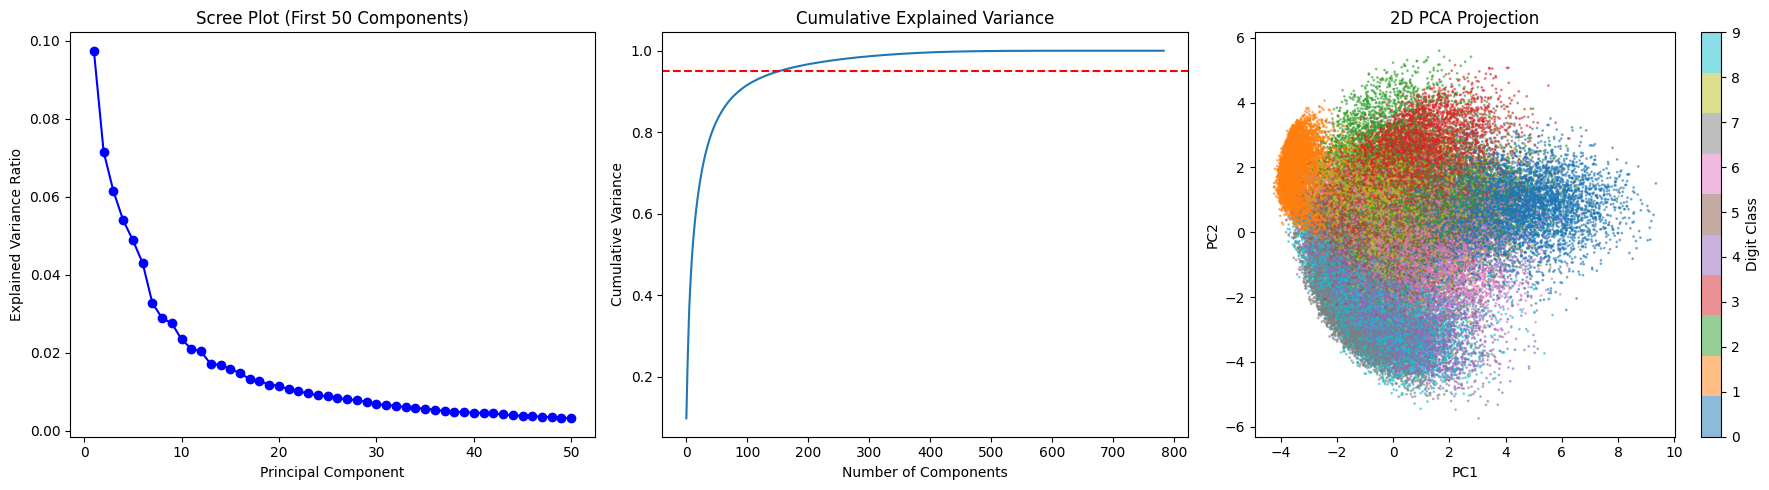

In [3]:
from sklearn.decomposition import PCA

# Apply PCA
pca_full = PCA().fit(X)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for variance thresholds
var_thresholds = [0.90, 0.95, 0.99]
for threshold in var_thresholds:
    n_comps = np.argmax(cumulative_variance >= threshold) + 1
    print(f"Components required for {int(threshold*100)}% variance: {n_comps}")

# Reduce to 2 and 50 dimensions
pca_2d = PCA(n_components=2).fit_transform(X)
X_pca_50 = PCA(n_components=50).fit_transform(X)

# Plotting
plt.figure(figsize=(18, 5))

# 1. Scree Plot (first 50 components)
plt.subplot(1, 3, 1)
plt.plot(range(1, 51), pca_full.explained_variance_ratio_[:50], 'bo-')
plt.title("Scree Plot (First 50 Components)")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

# 2. Cumulative Explained Variance Plot
plt.subplot(1, 3, 2)
plt.plot(cumulative_variance)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")

# 3. 2D PCA Projection
plt.subplot(1, 3, 3)
scatter = plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=y.astype(int), cmap='tab10', alpha=0.5, s=1)
plt.colorbar(scatter, label='Digit Class')
plt.title("2D PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()